### Importing

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from scipy import stats
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split , RandomizedSearchCV
from sklearn.metrics import ConfusionMatrixDisplay , classification_report , auc , roc_curve

### Loading Data

In [ ]:
df = pd.read_csv(filepath_or_buffer = "Mobile_price.csv")
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


### EDA

In [74]:
df.shape

(2000, 21)

In [75]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [76]:
df.duplicated().sum()

np.int64(0)

In [77]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [78]:
df.info(verbose = False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Columns: 21 entries, battery_power to price_range
dtypes: float64(2), int64(19)
memory usage: 328.3 KB


In [79]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


In [80]:
drop_cols = ["three_g" , "blue"]
df = df.drop(columns = drop_cols)

In [81]:
df["price_range"].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

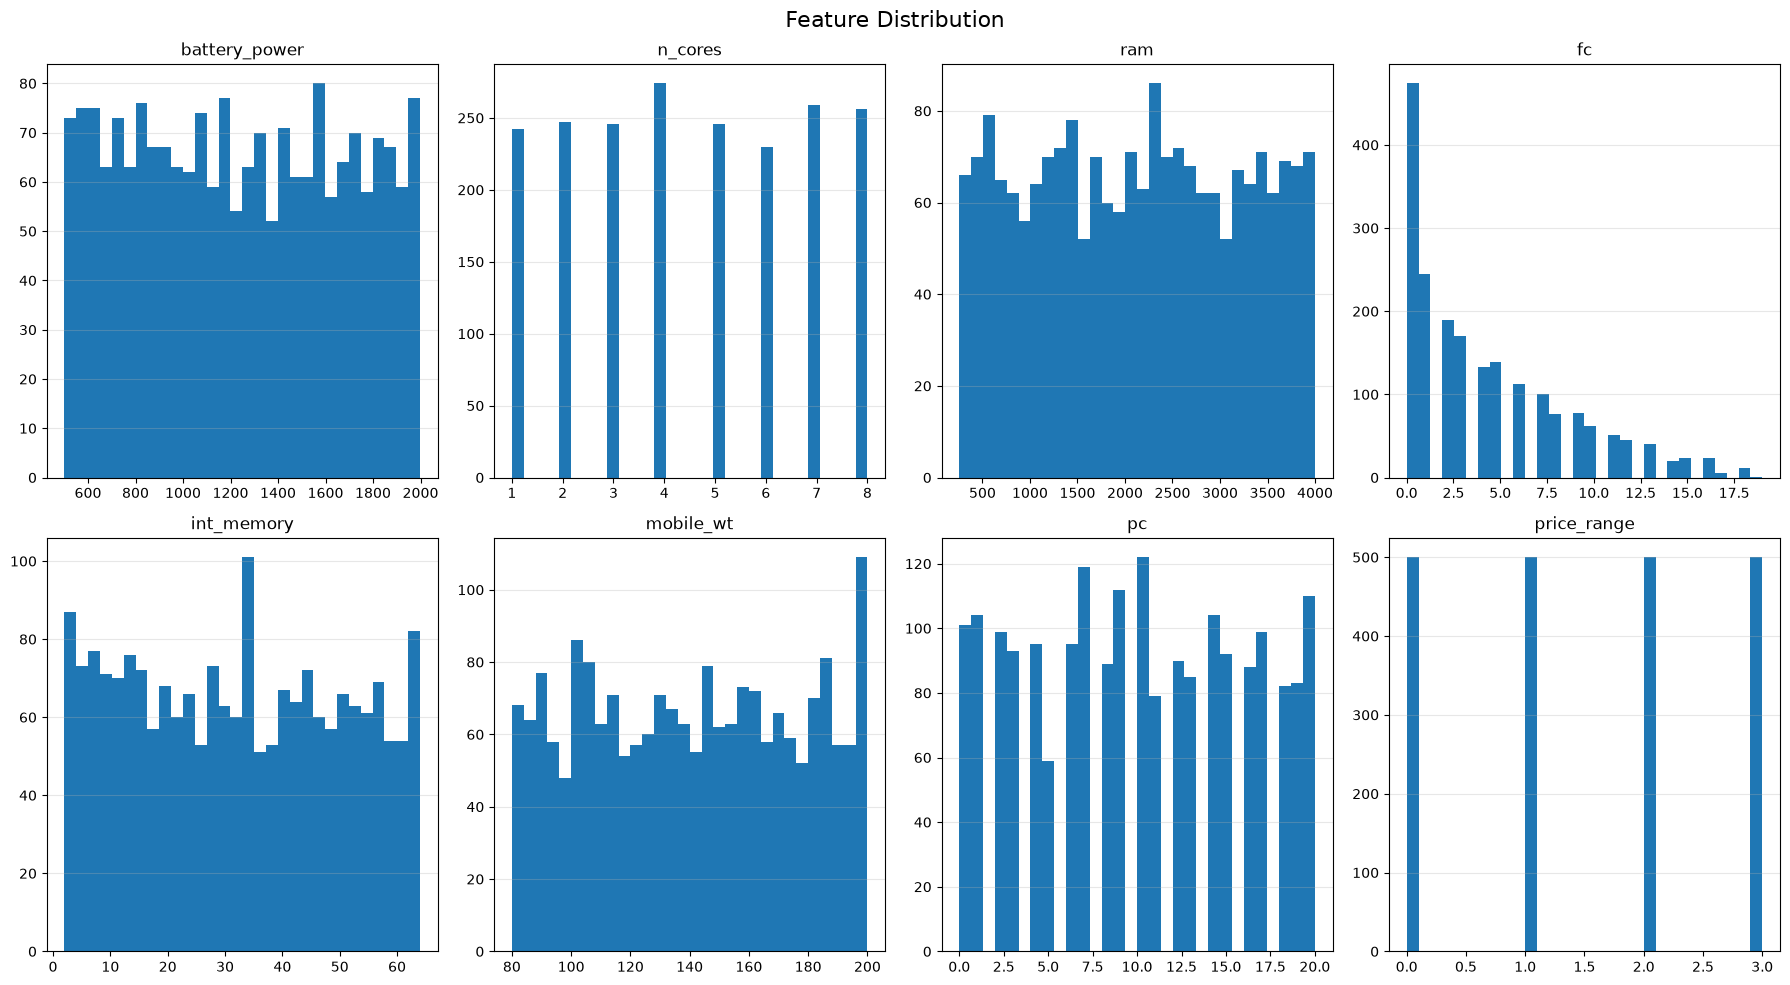

In [90]:
features = ["battery_power" , "n_cores" , "ram" , "fc" , "int_memory" , "mobile_wt" , "pc" , "price_range"]

fig , axes = plt.subplots(2 , 4 , figsize = (18 , 10))

for ax , feature in zip(axes.flatten() , features):
    ax.hist(df[feature] , bins = 30)
    ax.set_title(feature)
    ax.grid(axis = "y" , alpha = 0.3)

plt.suptitle("Feature Distribution" , fontsize = 16)
plt.tight_layout()
plt.show()

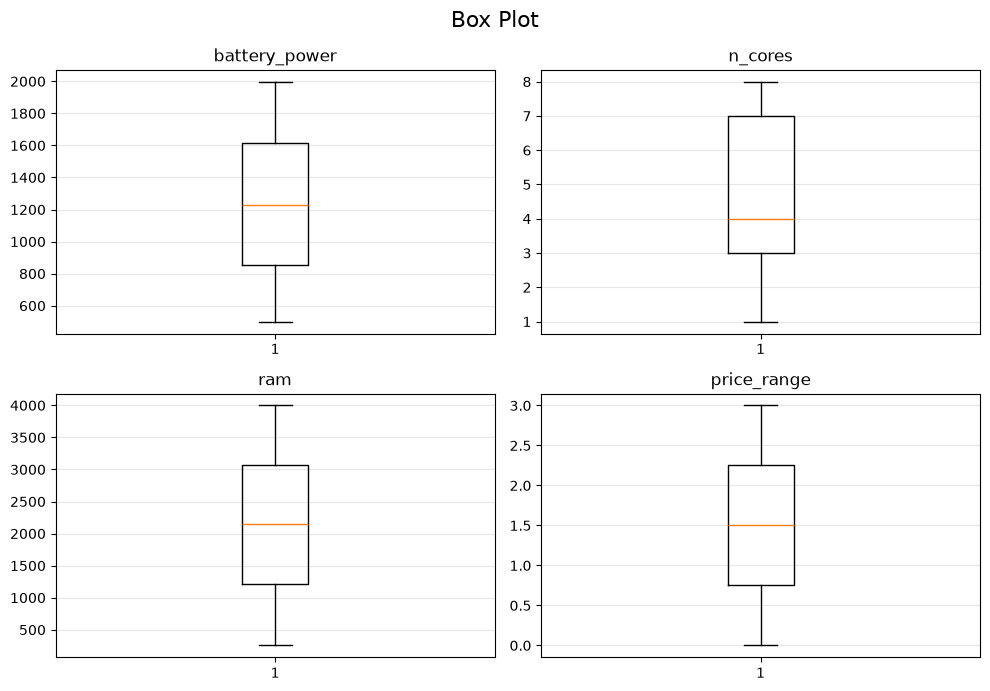

In [92]:
features = ["battery_power" , "n_cores" , "ram" , "price_range"]

fig , axes = plt.subplots(2 , 2 , figsize = (10 , 7))

for ax , feature in zip(axes.flatten() , features):
    ax.boxplot(df[feature])
    ax.set_title(feature)
    ax.grid(axis = "y" , alpha = 0.3)

plt.suptitle("Box Plot" , fontsize = 16)
plt.tight_layout()
plt.show()

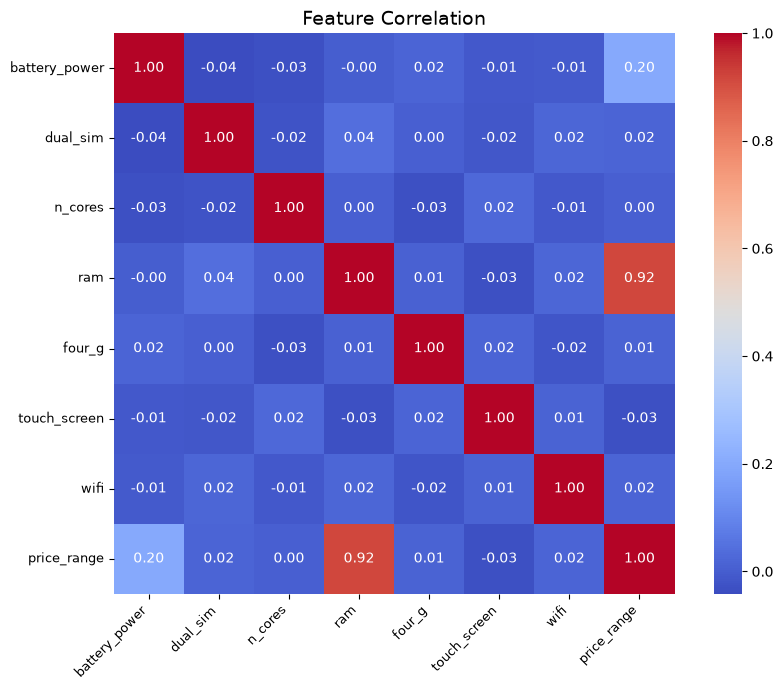

In [94]:
features = ["battery_power" , "dual_sim" , "n_cores" , "ram" , "four_g" , "touch_screen" , "wifi" , "price_range"]

plt.figure(figsize = (9 , 7))
sns.heatmap(df[features].corr() , annot = True , fmt = ".2f" , square = True , cmap = "coolwarm")

plt.title("Feature Correlation" , fontsize = 14)
plt.xticks(rotation = 45 , ha = "right" , fontsize = 9)
plt.yticks(fontsize = 9)
plt.tight_layout()
plt.show()

### Feature & Target Split

In [95]:
X = df.drop(columns = ["price_range"])
y = df["price_range"]

### Train & Test Split

In [96]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.22 , random_state = 101)

### RandomizedSearchCV & Model Training

In [97]:
xgb_model = XGBClassifier(objective = "multi:softprob" , random_state = 101)

In [98]:
param_distributions = {
    "n_estimators" : stats.randint(100 , 200) , 
    "max_depth" : stats.randint(2 , 7) , 
    "learning_rate" : stats.uniform(0.03 , 0.3) , 
}

In [99]:
rf_model = RandomizedSearchCV(estimator = xgb_model , param_distributions = param_distributions , scoring = "accuracy" ,
                              n_iter = 10 , cv = 5 , n_jobs = 1 , random_state = 101)
rf_model.fit(X_train , y_train)
rf_model.best_params_

{'learning_rate': np.float64(0.29808392390501914),
 'max_depth': 6,
 'n_estimators': 192}

### Prediction

In [100]:
y_pred = rf_model.predict(X_test)

### Evaluation

In [101]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94        98
           1       0.88      0.92      0.90       115
           2       0.95      0.88      0.91       132
           3       0.93      0.98      0.95        95

    accuracy                           0.93       440
   macro avg       0.93      0.93      0.93       440
weighted avg       0.93      0.93      0.92       440



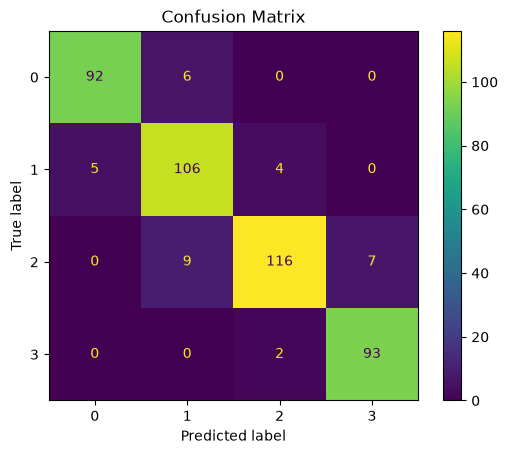

In [102]:
ConfusionMatrixDisplay.from_estimator(estimator = rf_model , X = X_test , y = y_test)
plt.title("Confusion Matrix")
plt.show()

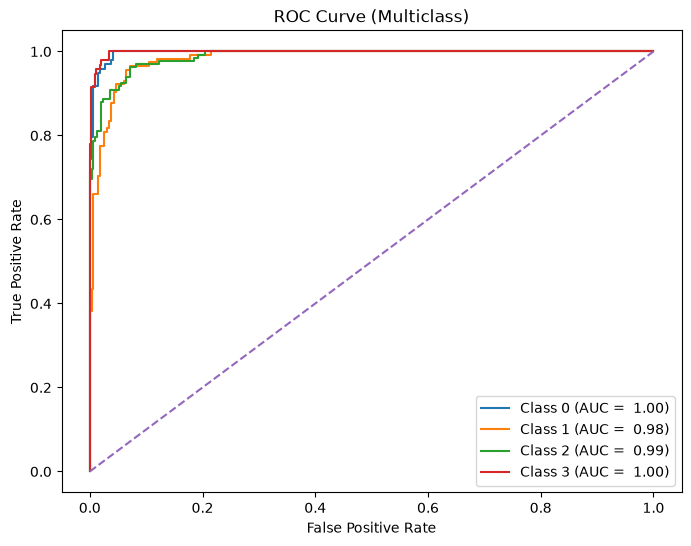

In [104]:
y_score = rf_model.predict_proba(X_test)

classes = rf_model.classes_

y_test_bin = label_binarize(y_test , classes = classes)

plt.figure(figsize = (8 , 6))

for i , cls in enumerate(classes):
    fpr , tpr , _ = roc_curve(y_test_bin[: , i] , y_score[: , i])
    roc_auc = auc(fpr , tpr)
    plt.plot(fpr , tpr , label = f"Class {cls} (AUC = {roc_auc : .2f})")

plt.plot([0 , 1] , [0 , 1] , "--")
plt.title("ROC Curve (Multiclass)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()